# Notebook 20 — Stronger SEI-only Aging Checkpoint Audit

## Goal

This notebook audits whether increasing SEI-only aging severity from 20 cycles to 50 and 100 cycles amplifies the weak degradation-state and voltage-curve descriptors observed in Notebooks 15–19.

The purpose is not to introduce a new degradation mechanism, but to increase the aging severity within the same SEI-only branch and determine whether weak feasibility-level descriptors become stronger aging-sensitive fingerprints.

## Scientific context

Previous notebooks established the diagnostic toolchain:

- Notebook 15: Metric Registry v0.1
- Notebook 16: fixed-endpoint pseudo-OCV feasibility
- Notebook 17: C/25 OCV-like / ICA / DVA feasibility
- Notebook 18: C/25 vs C/50 slow-rate validation
- Notebook 19: GITT-like finite-rest OCV reconstruction feasibility

Across these notebooks, the 20-cycle SEI-only branch produced technically extractable descriptors, but the signal magnitude remained weak:

- capacity fade ≈ 0.3%
- GITT-like finite-rest voltage drift ≈ −2 mV
- recovery-amplitude drift ≈ sub-mV
- ICA/DVA extractable but not yet mechanism-unique

Notebook 20 therefore increases SEI-only aging severity to test whether these weak descriptors scale with aging.

## Study design

Aging branch:

- Parameter set: OKane2022
- Aging mechanism: solvent-diffusion-limited SEI only
- Plating: disabled
- LAM: disabled
- particle mechanics: disabled
- SEI porosity change: disabled
- thermal model: isothermal

Checkpoints:

- 0 cycles
- 20 cycles
- 50 cycles
- 100 cycles

Initial audit layer:

- SEI thickness
- LLI
- total lithium lost
- capacity lost to side reactions
- monotonicity of degradation-state variables

Diagnostic branches such as C/25 V(Q), C/50 validation, or GITT-like reconstruction are deferred until the stronger aging-state signal is confirmed.

## Workflow

1. Rebuild SEI-only aging checkpoints at 0/20/50/100 cycles.
2. Extract degradation-state variables from each checkpoint.
3. Audit monotonicity and signal amplification.
4. Classify whether 50/100 cycles provide sufficient aging severity for downstream diagnostic branches.
5. Decide whether to proceed to capacity RPT, C/25 V(Q), and GITT-like reconstruction under stronger aging.

## Expected outputs

Data files:

- `data/stronger_sei_aging_state_table.csv`
- `data/stronger_sei_aging_monotonicity_audit.csv`
- `data/stronger_sei_aging_classification_table.csv`

Figures:

- `figures/stronger_sei_aging_degradation_state.png`
- `figures/stronger_sei_aging_capacity_loss.png`

## Interpretation boundary

This notebook audits aging severity, not diagnostic uniqueness.

If degradation-state variables scale monotonically with cycle count, then 50/100 cycles can be used as stronger checkpoints for subsequent diagnostic branches.

If degradation variables do not increase monotonically or the signal remains too weak, the SEI-only branch should remain classified as a weak voltage-fingerprint branch and other mechanisms such as plating or LAM should be prioritized.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


## Methodological boundary before code execution

Notebook 20 does not change the degradation mechanism.

The only intentional change is aging severity:

- 20 cycles from previous notebooks
- new stronger checkpoints at 50 and 100 cycles

Diagnostic branches are intentionally deferred until degradation-state scaling is confirmed.

In [2]:
# Cell 2 — SEI-only OKane2022 model builder（SEI-only OKane2022 模型构建函数）

def build_sei_only_model():
    """
    Build DFN model with solvent-diffusion-limited SEI only.
    Other degradation mechanisms are disabled to keep the fingerprint source isolated.
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }
    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")
    return model, parameter_values


def make_solver():
    """Create a conservative CasADi solver for degradation-enabled DFN runs."""
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


model_smoke, pv_smoke = build_sei_only_model()

print("[OK] SEI-only OKane2022 DFN model instantiated.")
print("[MODEL]", model_smoke.name)

[OK] SEI-only OKane2022 DFN model instantiated.
[MODEL] Doyle-Fuller-Newman model


In [3]:
# Cell 3 — Stronger aging protocol constants（增强老化检查点协议常数）

CHECKPOINT_CYCLES = [0, 20, 50, 100]

AGING_PERIOD = "120 seconds"

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

REFERENCE_REST_STEP = ["Rest for 10 minutes"]

print("[CONFIG] checkpoints:", CHECKPOINT_CYCLES)
print("[CONFIG] aging period:", AGING_PERIOD)
print("[CONFIG] aging cycle steps:")
for step in AGING_CYCLE_STEPS:
    print("  -", step)

print("[OK] Protocol constants defined.")

[CONFIG] checkpoints: [0, 20, 50, 100]
[CONFIG] aging period: 120 seconds
[CONFIG] aging cycle steps:
  - Discharge at C/3 until 2.5 V
  - Rest for 10 minutes
  - Charge at C/3 until 4.2 V
  - Hold at 4.2 V until C/100
  - Rest for 10 minutes
[OK] Protocol constants defined.


In [4]:
# Cell 4 — SEI-only stronger aging checkpoint runner（SEI-only 增强老化检查点生成）

def run_initial_reference_state(initial_soc=1.0):
    """
    Generate a 0-cycle reference solution for extracting initial degradation variables.
    This reference is not used to continue aging.
    """
    model, pv = build_sei_only_model()
    experiment = pybamm.Experiment(REFERENCE_REST_STEP, period=AGING_PERIOD)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    sol = sim.solve(initial_soc=initial_soc)
    return sol


def make_aging_experiment(n_cycles, period=AGING_PERIOD):
    """Build repeated SEI-only aging experiment."""
    if n_cycles == 0:
        return None
    return pybamm.Experiment([tuple(AGING_CYCLE_STEPS)] * n_cycles, period=period)


def run_aging_segment(n_cycles, starting_solution=None, initial_soc=None):
    """
    Run n_cycles of SEI-only aging.

    Returned solution is a pre-diagnostic aging state.
    Diagnostic branches must start from this solution but must not be used to continue aging.
    """
    if n_cycles == 0:
        return starting_solution

    model, pv = build_sei_only_model()
    experiment = make_aging_experiment(n_cycles)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    if initial_soc is not None:
        kwargs["initial_soc"] = initial_soc

    sol = sim.solve(**kwargs)
    return sol


checkpoint_solutions = {}

print("[RUN] Generating 0-cycle reference state")
checkpoint_solutions[0] = run_initial_reference_state(initial_soc=1.0)
print("[OK] checkpoint stored: 0 cycles")

current_solution = None
current_cycle = 0

t_start_all = time.perf_counter()

for target_cycle in CHECKPOINT_CYCLES[1:]:
    n_more = target_cycle - current_cycle
    print("")
    print(f"[RUN] Aging from cycle {current_cycle} to {target_cycle} ({n_more} cycles)")
    t_start = time.perf_counter()

    current_solution = run_aging_segment(
        n_cycles=n_more,
        starting_solution=current_solution,
        initial_soc=1.0 if current_cycle == 0 else None,
    )

    checkpoint_solutions[target_cycle] = current_solution
    current_cycle = target_cycle

    elapsed_min = (time.perf_counter() - t_start) / 60
    print(f"[OK] checkpoint stored: {target_cycle} cycles | elapsed = {elapsed_min:.2f} min")

elapsed_all_min = (time.perf_counter() - t_start_all) / 60

print("")
print("[OK] Stronger aging checkpoint generation complete.")
print("[CHECKPOINTS]", sorted(checkpoint_solutions.keys()))
print(f"[RUNTIME] total aging runtime = {elapsed_all_min:.2f} min")

[RUN] Generating 0-cycle reference state
[OK] checkpoint stored: 0 cycles

[RUN] Aging from cycle 0 to 20 (20 cycles)
[OK] checkpoint stored: 20 cycles | elapsed = 0.30 min

[RUN] Aging from cycle 20 to 50 (30 cycles)
[OK] checkpoint stored: 50 cycles | elapsed = 0.46 min

[RUN] Aging from cycle 50 to 100 (50 cycles)
[OK] checkpoint stored: 100 cycles | elapsed = 0.77 min

[OK] Stronger aging checkpoint generation complete.
[CHECKPOINTS] [0, 20, 50, 100]
[RUNTIME] total aging runtime = 1.53 min


In [5]:
# Cell 5 — Degradation-state variable extraction（老化状态变量提取）

VARIABLE_CANDIDATES = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative electrode SEI thickness [m]",
    ],
    "lli_percent": [
        "Loss of lithium inventory [%]",
        "Loss of lithium inventory, LLI [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Loss of lithium to SEI [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "sei_capacity_loss_Ah": [
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
        "Loss of capacity to SEI on negative electrode [A.h]",
        "Loss of capacity to side reactions [A.h]",
        "Total capacity lost to side reactions [A.h]",
    ],
}


def get_last_scalar(sol, candidates):
    """
    Return last scalar value from the first available PyBaMM variable candidate.
    If the variable is spatially resolved, use the last-time mean as fallback.
    """
    for name in candidates:
        try:
            entries = np.asarray(sol[name].entries, dtype=float)

            if entries.ndim == 0:
                value = float(entries)
            elif entries.ndim == 1:
                value = float(entries[-1])
            else:
                # spatial variable: take mean over non-time dimensions at final time
                value = float(np.nanmean(entries[..., -1]))

            return value, name
        except Exception:
            continue

    return np.nan, None


state_rows = []

for cycle in CHECKPOINT_CYCLES:
    sol = checkpoint_solutions[cycle]
    row = {"cycle": cycle}

    for metric, candidates in VARIABLE_CANDIDATES.items():
        value, used_name = get_last_scalar(sol, candidates)
        row[metric] = value
        row[f"{metric}_source"] = used_name

    state_rows.append(row)

aging_state_table = pd.DataFrame(state_rows)

state_path = DATA / "stronger_sei_aging_state_table.csv"
aging_state_table.to_csv(state_path, index=False)

print(f"[OK] saved: {state_path}")
display(aging_state_table)

missing = [
    col for col in ["sei_thickness_m", "lli_percent", "total_lithium_lost_mol", "sei_capacity_loss_Ah"]
    if aging_state_table[col].isna().all()
]

if missing:
    print("[WARNING] Some degradation variables were not found:", missing)
    print("[INFO] Inspect PyBaMM variable names containing SEI / lithium / capacity if needed.")

print("[OK] Degradation-state extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_aging_state_table.csv


,cycle,sei_thickness_m,sei_thickness_m_source,lli_percent,lli_percent_source,total_lithium_lost_mol,total_lithium_lost_mol_source,sei_capacity_loss_Ah,sei_capacity_loss_Ah_source
0,0,5.007573e-09,X-averaged negative SEI thickness [m],0.000093,Loss of lithium inventory [%],2.654362e-07,Total lithium lost [mol],0.000007,Loss of capacity to negative SEI [A.h]
1,20,9.471876e-09,X-averaged negative SEI thickness [m],0.055198,Loss of lithium inventory [%],1.567446e-04,Total lithium lost [mol],0.004201,Loss of capacity to negative SEI [A.h]
2,50,1.366499e-08,X-averaged negative SEI thickness [m],0.106956,Loss of lithium inventory [%],3.037184e-04,Total lithium lost [mol],0.008140,Loss of capacity to negative SEI [A.h]
3,100,1.866443e-08,X-averaged negative SEI thickness [m],0.168666,Loss of lithium inventory [%],4.789546e-04,Total lithium lost [mol],0.012837,Loss of capacity to negative SEI [A.h]


[OK] Degradation-state extraction complete.


In [6]:
# Cell 6 — Degradation-state monotonicity and amplification audit（老化状态单调性与信号增强审计）

metric_cols = [
    "sei_thickness_m",
    "lli_percent",
    "total_lithium_lost_mol",
    "sei_capacity_loss_Ah",
]

audit_rows = []

for metric in metric_cols:
    values = aging_state_table[metric].to_numpy(dtype=float)
    valid = np.isfinite(values)

    if valid.sum() < 2:
        audit_rows.append({
            "metric": metric,
            "available": False,
            "monotonic_non_decreasing": False,
            "value_0": np.nan,
            "value_20": np.nan,
            "value_50": np.nan,
            "value_100": np.nan,
            "delta_20_minus_0": np.nan,
            "delta_50_minus_0": np.nan,
            "delta_100_minus_0": np.nan,
            "amplification_100_vs_20": np.nan,
            "classification": "not available",
        })
        continue

    diffs = np.diff(values[valid])
    monotonic = bool(np.all(diffs >= -1e-12))

    cycle_values = dict(zip(aging_state_table["cycle"], values))

    v0 = cycle_values.get(0, np.nan)
    v20 = cycle_values.get(20, np.nan)
    v50 = cycle_values.get(50, np.nan)
    v100 = cycle_values.get(100, np.nan)

    d20 = v20 - v0 if np.isfinite(v20) and np.isfinite(v0) else np.nan
    d50 = v50 - v0 if np.isfinite(v50) and np.isfinite(v0) else np.nan
    d100 = v100 - v0 if np.isfinite(v100) and np.isfinite(v0) else np.nan

    amp = d100 / d20 if np.isfinite(d100) and np.isfinite(d20) and abs(d20) > 1e-15 else np.nan

    if monotonic and np.isfinite(amp) and amp >= 3:
        classification = "monotonic and amplified"
    elif monotonic:
        classification = "monotonic but weak amplification"
    else:
        classification = "non-monotonic"

    audit_rows.append({
        "metric": metric,
        "available": True,
        "monotonic_non_decreasing": monotonic,
        "value_0": v0,
        "value_20": v20,
        "value_50": v50,
        "value_100": v100,
        "delta_20_minus_0": d20,
        "delta_50_minus_0": d50,
        "delta_100_minus_0": d100,
        "amplification_100_vs_20": amp,
        "classification": classification,
    })

monotonicity_audit = pd.DataFrame(audit_rows)

audit_path = DATA / "stronger_sei_aging_monotonicity_audit.csv"
monotonicity_audit.to_csv(audit_path, index=False)

print(f"[OK] saved: {audit_path}")
display(monotonicity_audit)

assert monotonicity_audit.query("available == True")["monotonic_non_decreasing"].all(), (
    "At least one available degradation-state metric is non-monotonic."
)

print("[OK] Available degradation-state metrics are monotonic.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_aging_monotonicity_audit.csv


,metric,available,monotonic_non_decreasing,value_0,value_20,value_50,value_100,delta_20_minus_0,delta_50_minus_0,delta_100_minus_0,amplification_100_vs_20,classification
0,sei_thickness_m,True,True,5.007573e-09,9.471876e-09,1.366499e-08,1.866443e-08,4.464304e-09,8.657422e-09,1.365686e-08,3.059124,monotonic and amplified
1,lli_percent,True,True,9.347460e-05,5.519835e-02,1.069559e-01,1.686661e-01,5.510488e-02,1.068624e-01,1.685726e-01,3.059124,monotonic and amplified
2,total_lithium_lost_mol,True,True,2.654362e-07,1.567446e-04,3.037184e-04,4.789546e-04,1.564792e-04,3.034530e-04,4.786892e-04,3.059124,monotonic and amplified
3,sei_capacity_loss_Ah,True,True,7.114083e-06,4.200988e-03,8.140103e-03,1.283669e-02,4.193874e-03,8.132989e-03,1.282958e-02,3.059124,monotonic and amplified


[OK] Available degradation-state metrics are monotonic.


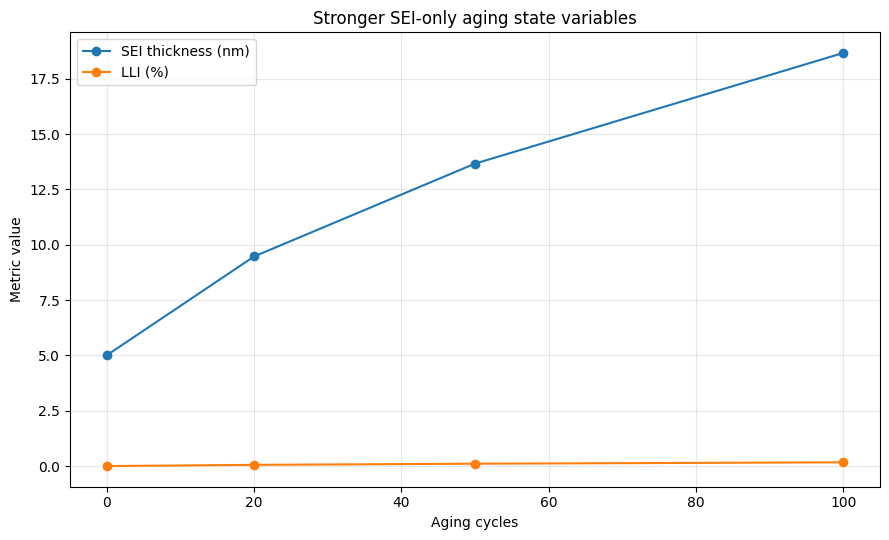

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_aging_degradation_state.png


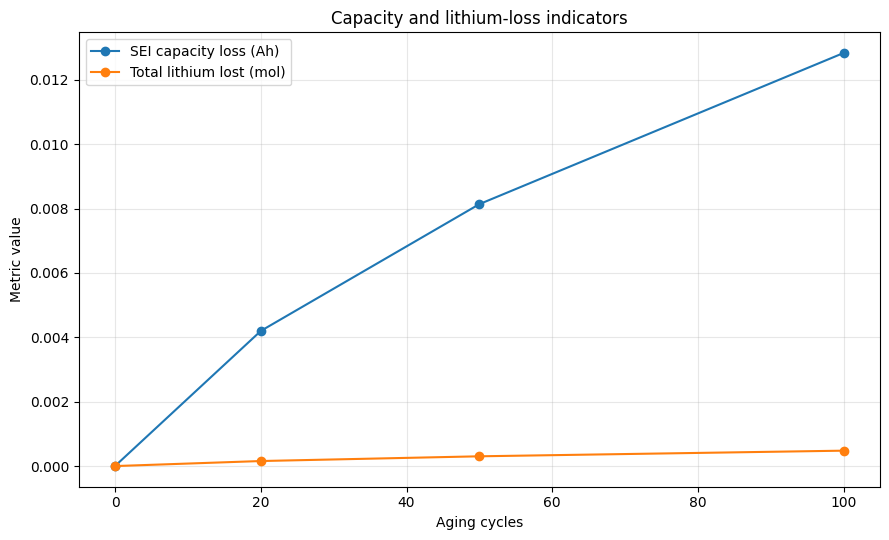

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/stronger_sei_aging_capacity_loss.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/stronger_sei_aging_classification_table.csv


,metric_layer,evidence,strength,classification
0,degradation_state_availability,4 degradation-state metrics available.,data-backed,degradation-state extraction available
1,monotonicity,4/4 available metrics are monotonic non-decrea...,strong,SEI-only degradation state increases monotonic...
2,amplification,4/4 available metrics show >=3x amplification ...,screening-level,stronger checkpoints likely improve diagnostic...
3,overall,0/20/50/100 cycle SEI-only checkpoints were ge...,supported,50/100-cycle SEI-only aging checkpoints provid...


In [7]:
# Cell 7 — Degradation-state visualization and classification（老化状态可视化与分类）

# Figure 1 — SEI / LLI / lithium lost
plt.figure(figsize=(9, 5.5))

if "sei_thickness_m" in aging_state_table:
    plt.plot(
        aging_state_table["cycle"],
        aging_state_table["sei_thickness_m"] * 1e9,
        marker="o",
        label="SEI thickness (nm)"
    )

if "lli_percent" in aging_state_table and aging_state_table["lli_percent"].notna().any():
    plt.plot(
        aging_state_table["cycle"],
        aging_state_table["lli_percent"],
        marker="o",
        label="LLI (%)"
    )

plt.xlabel("Aging cycles")
plt.ylabel("Metric value")
plt.title("Stronger SEI-only aging state variables")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_aging_degradation_state.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — capacity / lithium loss
plt.figure(figsize=(9, 5.5))

if "sei_capacity_loss_Ah" in aging_state_table and aging_state_table["sei_capacity_loss_Ah"].notna().any():
    plt.plot(
        aging_state_table["cycle"],
        aging_state_table["sei_capacity_loss_Ah"],
        marker="o",
        label="SEI capacity loss (Ah)"
    )

if "total_lithium_lost_mol" in aging_state_table and aging_state_table["total_lithium_lost_mol"].notna().any():
    plt.plot(
        aging_state_table["cycle"],
        aging_state_table["total_lithium_lost_mol"],
        marker="o",
        label="Total lithium lost (mol)"
    )

plt.xlabel("Aging cycles")
plt.ylabel("Metric value")
plt.title("Capacity and lithium-loss indicators")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "stronger_sei_aging_capacity_loss.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Overall classification
available_metrics = monotonicity_audit[monotonicity_audit["available"] == True]
n_available = len(available_metrics)
n_monotonic = int(available_metrics["monotonic_non_decreasing"].sum())
n_amplified = int((available_metrics["classification"] == "monotonic and amplified").sum())

if n_available > 0 and n_monotonic == n_available and n_amplified >= 1:
    overall_strength = "supported"
    overall_classification = "50/100-cycle SEI-only aging checkpoints provide stronger aging severity"
elif n_available > 0 and n_monotonic == n_available:
    overall_strength = "partially supported"
    overall_classification = "SEI-only aging remains monotonic but amplification is limited"
else:
    overall_strength = "deferred"
    overall_classification = "stronger SEI-only aging checkpoint design requires revision"

classification_table = pd.DataFrame([
    {
        "metric_layer": "degradation_state_availability",
        "evidence": f"{n_available} degradation-state metrics available.",
        "strength": "data-backed",
        "classification": "degradation-state extraction available",
    },
    {
        "metric_layer": "monotonicity",
        "evidence": f"{n_monotonic}/{n_available} available metrics are monotonic non-decreasing.",
        "strength": "strong" if n_monotonic == n_available else "insufficient",
        "classification": "SEI-only degradation state increases monotonically" if n_monotonic == n_available else "non-monotonic degradation-state behavior detected",
    },
    {
        "metric_layer": "amplification",
        "evidence": f"{n_amplified}/{n_available} available metrics show >=3x amplification at 100 cycles relative to 20 cycles.",
        "strength": "screening-level",
        "classification": "stronger checkpoints likely improve diagnostic observability" if n_amplified >= 1 else "signal amplification may remain limited",
    },
    {
        "metric_layer": "overall",
        "evidence": "0/20/50/100 cycle SEI-only checkpoints were generated and audited.",
        "strength": overall_strength,
        "classification": overall_classification,
    },
])

classification_path = DATA / "stronger_sei_aging_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(classification_table)

## Final closure — Notebook 20

### Key findings

Notebook 20 audited whether increasing SEI-only aging severity from 20 cycles to 50 and 100 cycles amplifies the degradation-state signal within the same SEI-only branch.

The degradation mechanism was not changed. The model configuration remained aligned with the previous SEI-only notebooks:

- OKane2022 parameter set,
- solvent-diffusion-limited SEI,
- lithium plating disabled,
- LAM disabled,
- particle mechanics disabled,
- SEI porosity change disabled,
- isothermal model.

The only intentional change was the aging checkpoint severity:

- 0 cycles,
- 20 cycles,
- 50 cycles,
- 100 cycles.

The stronger aging checkpoint generation completed successfully. The total runtime was approximately 1.53 min.

Four degradation-state metrics were extracted successfully:

- SEI thickness,
- loss of lithium inventory (LLI),
- total lithium lost,
- capacity lost to negative SEI.

All four metrics increased monotonically with cycle number.

From 0 to 100 cycles:

- SEI thickness increased from approximately 5.01 nm to 18.66 nm;
- LLI increased from approximately 0.00009% to 0.1687%;
- total lithium lost increased from approximately 2.65e-7 mol to 4.79e-4 mol;
- SEI capacity loss increased from approximately 0.000007 Ah to 0.01284 Ah.

Relative to the 20-cycle checkpoint, the 100-cycle checkpoint increased the degradation-state signal by approximately 3.06× for all available degradation-state metrics.

The monotonicity audit passed:

- 4/4 available degradation-state metrics were monotonic non-decreasing;
- 4/4 available metrics showed at least 3× amplification at 100 cycles relative to 20 cycles.

### Interpretation boundary

Notebook 20 audits aging severity only. It does not yet establish diagnostic uniqueness.

The result confirms that 50-cycle and 100-cycle checkpoints provide stronger SEI-only aging states for subsequent diagnostic branches. It does not by itself prove that voltage-curve, ICA/DVA, or GITT-like descriptors become mechanism-unique fingerprints.

The absolute degradation magnitude remains moderate. At 100 cycles, SEI capacity loss is approximately 0.01284 Ah and LLI is approximately 0.1687%. Therefore, stronger downstream diagnostic signals are expected relative to 20 cycles, but large voltage or derivative-feature shifts should not be assumed in advance.

### Correct conclusion wording

Supported:

- SEI-only degradation-state variables are available and extractable.
- SEI thickness, LLI, lithium loss, and SEI capacity loss increase monotonically from 0 to 100 cycles.
- 50-cycle and 100-cycle checkpoints provide stronger aging severity than the 20-cycle checkpoint.
- The 100-cycle checkpoint amplifies the degradation-state signal by approximately 3.06× relative to 20 cycles.
- These checkpoints are suitable for downstream diagnostic-branch audits.

Not supported:

- This notebook does not prove a mechanism-unique SEI diagnostic fingerprint.
- This notebook does not show that ICA/DVA or GITT-like voltage descriptors become strongly separable at 100 cycles.
- This notebook does not compare SEI-only against plating, LAM, or other degradation mechanisms.
- This notebook does not yet establish experimental observability.

### Classification

`50/100-cycle SEI-only aging checkpoints = supported`

Project-level wording:

> Stronger SEI-only aging checkpoints at 50 and 100 cycles provide monotonic and amplified degradation-state signals. They are suitable for downstream diagnostic audits, but diagnostic uniqueness remains to be tested.

### Next step

The next logical step is to run stronger-checkpoint diagnostic branches using the 0/20/50/100-cycle aging states.

Recommended next notebook:

`21_stronger_sei_diagnostic_branch_audit.ipynb`

The priority diagnostic branches should be:

1. capacity RPT / external capacity check,
2. C/25 OCV-like V(Q),
3. GITT-like finite-rest OCV reconstruction.

ICA/DVA interpretation should remain secondary until voltage-curve drift becomes clearly larger than protocol and smoothing sensitivity.